# Partition Cell Types for UMAP ploting

To ensure that our cell type labels are as accurate as possible, we'll subset our dataset based on our `AIFI_L3` labels for review.

After performing leiden clusters, plot umaps and rank genes

Map previously labelled doublet cells to UMAP embeddings to annotate new doublet cell clusters 

## Load libraries

In [157]:
%config Completer.use_jedi = False

import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)
warnings.simplefilter(action='ignore', category=RuntimeWarning)

import concurrent.futures
from concurrent.futures import ThreadPoolExecutor
from datetime import date
import hisepy
import os
import pandas as pd
import re
import scanpy as sc
import scanpy.external as sce
import glob
import math
import matplotlib.pyplot as plt
import quilter # best to put this after your matplotlib import
from PIL import Image
from PIL import ImageDraw

In [2]:
out_dir = 'output'
if not os.path.isdir(out_dir):
    os.makedirs(out_dir)

## Helper functions

In [3]:
def cache_uuid_path(uuid):
    cache_path = '/home/jupyter/cache/{u}'.format(u = uuid)
    if not os.path.isdir(cache_path):
        hise_res = hisepy.reader.cache_files([uuid])
    filename = os.listdir(cache_path)[0]
    cache_file = '{p}/{f}'.format(p = cache_path, f = filename)
    return cache_file

In [4]:
def read_parquet_uuid(uuid):
    cache_file = cache_uuid_path(uuid)
    res = pd.read_parquet(cache_file)
    return res

In [5]:
def sort_adata_uuid(uuid, sort_cols = ['AIFI_L2', 'sample.sampleKitGuid']):
    cache_file = cache_uuid_path(uuid)
    adata = sc.read_h5ad(cache_file)
    obs = adata.obs
    obs = obs.sort_values(sort_cols)
    adata = adata[obs.index]
    adata.write_h5ad(cache_file)

This function will enable us to connect to our .h5ad files without loading the entire thing into memory. We'll then load only the cells that we want for each cell class to assemble them for writing. This should save us some overhead as we do our subsetting.

In [6]:
def read_adata_backed_uuid(uuid):
    cache_file = cache_uuid_path(uuid)
    res = sc.read_h5ad(cache_file, backed = 'r')
    return res

This function will remove Ig-related genes, which is recommended by Marla Glass for analysis of B cell subtypes

In [7]:
def remove_ig_genes(adata):
    igl_genes = [gene for gene in adata.var_names if gene.startswith("IGL")]
    igk_genes = [gene for gene in adata.var_names if gene.startswith("IGK")]
    ighc_genes = [gene for gene in adata.var_names if gene.startswith("IGH")]
    exl_genes = igl_genes + igk_genes + ighc_genes

    filtered_genes = [gene for gene in adata.var_names if gene not in exl_genes]
    adata = adata[:, filtered_genes]

    return adata

In [8]:
def read_anndata_files(file_tuples):
    """
    Read Anndata objects from H5AD files and store them in a dictionary with custom names.

    Parameters:
        file_tuples (list of tuples): List of tuples where each tuple contains filename and desired name.

    Returns:
        dict: Dictionary containing Anndata objects with custom names.
    """
    anndata_dict = {}
    for filename, name in file_tuples:
        anndata_obj = anndata.read_h5ad(filename)
        anndata_dict[name] = anndata_obj
    return anndata_dict

In [9]:
def format_cell_type(cell_type):
    cell_type = re.sub('\\+', 'pos', cell_type)
    cell_type = re.sub('-', 'neg', cell_type)
    cell_type = re.sub(' ', '_', cell_type)
    return cell_type

In [29]:
def reformat_cell_type(cell_type):
    '''convert cell type names read in from file back to original L3 labels'''
    cell_type = re.sub('pos', '+', cell_type)
    cell_type = re.sub('neg', '-', cell_type)
    cell_type = re.sub('_',' ', cell_type)
    return cell_type

In [12]:
def element_id(n = 3):
    import periodictable
    from random import randrange
    rand_el = []
    for i in range(n):
        el = randrange(0,118)
        rand_el.append(periodictable.elements[el].name)
    rand_str = '-'.join(rand_el)
    return rand_str

In [14]:
# make a function to find files
def get_filepaths_with_glob(root_path: str, file_regex: str):
    return glob.glob(os.path.join(root_path, file_regex))

In [20]:
# Define a function to extract the desired substring using regex
def extract_substring(path):
    pattern = r'preRA_cluster_harmonize_(.*?)_\d{4}-\d{2}-\d{2}\.h5ad'
    match = re.search(pattern, path)
    if match:
        return match.group(1)
    return None


In [233]:
def plot_rank_genes(adata):
    df = sc.get.rank_genes_groups_df(adata, group=None)
    df = df.groupby('group').head(20).reset_index(drop=True)
    groups = df.groupby('group')
    df

    n_groups = len(groups)
    n_cols = 10
    n_rows = math.ceil(n_groups / n_cols)
    
    fig, axs = plt.subplots(n_rows, n_cols, figsize=(15, n_rows * 5))
    fig.suptitle(adata.obs['AIFI_L3'][0], fontsize=50)
    
    if n_rows == 1:
        axs = axs.reshape(1, -1)
    
    for ax in axs.flat:
        ax.set_visible(False)
    
    for i, (name, group) in enumerate(groups):
        row, col = divmod(i, n_cols)
        ax = axs[row, col]
        ax.set_visible(True)
        ax.scatter(group['scores'], group['names'])
        ax.invert_yaxis()
        ax.set_title(str(name) + " vs Rest")
        ax.set_xlabel('T-Statistics')
        ax.set_ylabel('Gene')
    
    plt.tight_layout()
    return(plt)


## Read in data

In [15]:
output_path = "./output/"

In [23]:
### read in processed leiden adata
filenames = get_filepaths_with_glob(output_path, "preRA_cluster_harmonize_*.h5ad")  

In [24]:
### extract cell types
# Apply the function to each filename in the list using list comprehension
cell_types = [extract_substring(path) for path in filenames]

# Print the result


In [30]:
## reformat cell types
#cell_types2 = [reformat_cell_type(cell_type) for cell_type in cell_types]

In [149]:
file_dict = dict(zip(cell_types, filenames))

In [151]:
list(file_dict.items())[:20]

[('CD4_MAIT', './output/preRA_cluster_harmonize_CD4_MAIT_2024-05-25.h5ad'),
 ('ISGpos_naive_CD8_T_cell',
  './output/preRA_cluster_harmonize_ISGpos_naive_CD8_T_cell_2024-05-26.h5ad'),
 ('Adaptive_NK_cell',
  './output/preRA_cluster_harmonize_Adaptive_NK_cell_2024-05-25.h5ad'),
 ('Early_memory_B_cell',
  './output/preRA_cluster_harmonize_Early_memory_B_cell_2024-05-26.h5ad'),
 ('CD56bright_NK_cell',
  './output/preRA_cluster_harmonize_CD56bright_NK_cell_2024-05-25.h5ad'),
 ('Intermediate_monocyte',
  './output/preRA_cluster_harmonize_Intermediate_monocyte_2024-05-26.h5ad'),
 ('Core_naive_CD8_T_cell',
  './output/preRA_cluster_harmonize_Core_naive_CD8_T_cell_2024-05-26.h5ad'),
 ('Transitional_B_cell',
  './output/preRA_cluster_harmonize_Transitional_B_cell_2024-05-26.h5ad'),
 ('pDC', './output/preRA_cluster_harmonize_pDC_2024-05-26.h5ad'),
 ('KLRF1pos_GZMBpos_CD27neg_EM_CD8_T_cell',
  './output/preRA_cluster_harmonize_KLRF1pos_GZMBpos_CD27neg_EM_CD8_T_cell_2024-05-26.h5ad'),
 ('CM_CD4_T_

In [155]:
# make test subset
subfile_dict = {'CD4_MAIT':'./output/preRA_cluster_harmonize_CD4_MAIT_2024-05-25.h5ad'}
subfile_dict

{'CD4_MAIT': './output/preRA_cluster_harmonize_CD4_MAIT_2024-05-25.h5ad'}

In [102]:
### read in doublet metadata from 141 scRNA seq run

doublet_meta = pd.read_csv("../data/ALTRA_qc_filtered_meta_certpro.csv", index_col=0)
#doublet_meta.set_index('barcodes')
#if 'barcodes' in doublet_meta.columns:
 #   doublet_meta = doublet_meta.rename(columns={'barcodes': 'barcodes_col'})
# Reset the index to make 'barcodes' a column
#doublet_meta = doublet_meta.reset_index()
doublet_meta.head()

,barcodes,sample.sampleKitGuid,subject.subjectGuid,subject.biologicalSex,doublets_manual
0,cf71f16e48b611ea8957bafe6d70929e,KT00070,CU1001,Male,yes
1,cf71f28648b611ea8957bafe6d70929e,KT00070,CU1001,Male,no
2,cf72006448b611ea8957bafe6d70929e,KT00070,CU1001,Male,no
3,cf72038e48b611ea8957bafe6d70929e,KT00070,CU1001,Male,yes
4,cf72044248b611ea8957bafe6d70929e,KT00070,CU1001,Male,no


In [ ]:
for label, file in file_dict.items():
    print("Key:", label)
    print("Value:", file)

    adata = sc.read_h5ad(file)
    print(adata)

    meta = adata.obs

    # Check for conflict and drop the index if a column has the same name
    if 'barcodes' in meta.index.names and 'barcodes' in meta.columns:
        meta = meta.reset_index(drop=True)
    #meta.head()

    # Perform the merge
    meta2 = pd.merge(meta, doublet_meta, how='left', on=['barcodes', 'sample.sampleKitGuid', 'subject.subjectGuid', 'subject.biologicalSex'])
    
    # Print the result
    #print(meta2.head())
    
    # add back to adata
    adata.obs = meta2

    print(adata)

    p1 = sc.pl.umap(adata, 
               color=['doublet_score', 'S100A9','AIFI_L2' , 'CD3E',  
                      'HBB','PF4', 'MS4A1','sample.visitName'],
               ncols=3, 
              # save='_UMAP.png',
                    return_fig = True)

     p2 = sc.pl.umap(adata, 
               color=['doublets_manual'],
               ncols=3, 
               #save='_UMAP_leiden.png',
               #legend_loc='on data',
               return_fig = True,)
    
    # Plot specifically for 'leiden' with legend on the data points
    p3 = sc.pl.umap(adata, 
               color=['leiden_harmony_2', 'doublets_manual'],
               ncols=3, 
               #save='_UMAP_leiden.png',
               legend_loc='on data',return_fig = True,title = label)

    umaps = p3 / p1

    umap_output = "../results/" + label+"_umaps.png"
    umaps.savefig(umap_output)
    
    p = plot_rank_genes(adata)
    print(p)

    rank_output = "../results/" + label+"_rank_genes.png"

    p.savefig(rank_output)

    '''
    img3 = Image.open('figures/umap_UMAP_leiden.png')
    img2 = Image.open('figures/umap_UMAP.png')
    img1 = Image.open('./figures//'+'scatter_plots.png')

    total_width = max(img1.width, img2.width, img3.width)
    font_size = 20 
    title_height = font_size * 2  
    total_height = img1.height + img2.height + img3.height + title_height + 100  # Adjusted for spacing

    combined_img = Image.new('RGB', (total_width, total_height), 'white')  

    draw = ImageDraw.Draw(combined_img)

    combined_img.paste(img1, (0, title_height))
    combined_img.paste(img2, (0, title_height + img1.height + 100))  # Adjusted for spacing
    combined_img.paste(img3, (0, title_height + img1.height + img2.height + 100))  # Adjusted for spacing

    combined_img.save(output_file)

    '''

    
    

Key: CD4_MAIT
Value: ./output/preRA_cluster_harmonize_CD4_MAIT_2024-05-25.h5ad
AnnData object with n_obs × n_vars = 4270 × 33538
    obs: 'barcodes', 'batch_id', 'cell_name', 'cell_uuid', 'chip_id', 'hto_barcode', 'hto_category', 'n_genes', 'n_mito_umis', 'n_reads', 'n_umis', 'original_barcodes', 'pbmc_sample_id', 'pool_id', 'well_id', 'sample.sampleKitGuid', 'cohort.cohortGuid', 'subject.subjectGuid', 'subject.biologicalSex', 'subject.race', 'subject.ethnicity', 'subject.birthYear', 'sample.visitName', 'sample.drawDate', 'sample.diseaseStatesRecordedAtVisit', 'sample.daysSinceFirstVisit', 'file.id', 'subset_grp', 'predicted_doublet', 'doublet_score', 'AIFI_L1', 'AIFI_L1_score', 'AIFI_L2', 'AIFI_L2_score', 'AIFI_L3', 'AIFI_L3_score', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mito', 'log1p_total_counts_mito',

/opt/conda/lib/python3.10/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(
/opt/conda/lib/python3.10/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


/opt/conda/lib/python3.10/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(
/opt/conda/lib/python3.10/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


<module 'matplotlib.pyplot' from '/opt/conda/lib/python3.10/site-packages/matplotlib/pyplot.py'>
Key: ISGpos_naive_CD8_T_cell
Value: ./output/preRA_cluster_harmonize_ISGpos_naive_CD8_T_cell_2024-05-26.h5ad
AnnData object with n_obs × n_vars = 2299 × 33538
    obs: 'barcodes', 'batch_id', 'cell_name', 'cell_uuid', 'chip_id', 'hto_barcode', 'hto_category', 'n_genes', 'n_mito_umis', 'n_reads', 'n_umis', 'original_barcodes', 'pbmc_sample_id', 'pool_id', 'well_id', 'sample.sampleKitGuid', 'cohort.cohortGuid', 'subject.subjectGuid', 'subject.biologicalSex', 'subject.race', 'subject.ethnicity', 'subject.birthYear', 'sample.visitName', 'sample.drawDate', 'sample.diseaseStatesRecordedAtVisit', 'sample.daysSinceFirstVisit', 'file.id', 'subset_grp', 'predicted_doublet', 'doublet_score', 'AIFI_L1', 'AIFI_L1_score', 'AIFI_L2', 'AIFI_L2_score', 'AIFI_L3', 'AIFI_L3_score', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_i

/opt/conda/lib/python3.10/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(
/opt/conda/lib/python3.10/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(
/opt/conda/lib/python3.10/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(
/opt/conda/lib/python3.10/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


...

/opt/conda/lib/python3.10/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


/opt/conda/lib/python3.10/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(
/opt/conda/lib/python3.10/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(
/opt/conda/lib/python3.10/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


<module 'matplotlib.pyplot' from '/opt/conda/lib/python3.10/site-packages/matplotlib/pyplot.py'>
Key: GZMBneg_CD27pos_EM_CD4_T_cell
Value: ./output/preRA_cluster_harmonize_GZMBneg_CD27pos_EM_CD4_T_cell_2024-05-26.h5ad
AnnData object with n_obs × n_vars = 326393 × 33538
    obs: 'barcodes', 'batch_id', 'cell_name', 'cell_uuid', 'chip_id', 'hto_barcode', 'hto_category', 'n_genes', 'n_mito_umis', 'n_reads', 'n_umis', 'original_barcodes', 'pbmc_sample_id', 'pool_id', 'well_id', 'sample.sampleKitGuid', 'cohort.cohortGuid', 'subject.subjectGuid', 'subject.biologicalSex', 'subject.race', 'subject.ethnicity', 'subject.birthYear', 'sample.visitName', 'sample.drawDate', 'sample.diseaseStatesRecordedAtVisit', 'sample.daysSinceFirstVisit', 'file.id', 'subset_grp', 'predicted_doublet', 'doublet_score', 'AIFI_L1', 'AIFI_L1_score', 'AIFI_L2', 'AIFI_L2_score', 'AIFI_L3', 'AIFI_L3_score', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes',

/opt/conda/lib/python3.10/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(
/opt/conda/lib/python3.10/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


/opt/conda/lib/python3.10/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(
/opt/conda/lib/python3.10/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


In [92]:
meta = adata.obs

In [97]:
# Check for conflict and drop the index if a column has the same name
if 'barcodes' in meta.index.names and 'barcodes' in meta.columns:
    meta = meta.reset_index(drop=True)
meta.head()

,barcodes,batch_id,cell_name,cell_uuid,chip_id,hto_barcode,hto_category,n_genes,n_mito_umis,n_reads,...,total_counts,log1p_total_counts,pct_counts_in_top_50_genes,pct_counts_in_top_100_genes,pct_counts_in_top_200_genes,pct_counts_in_top_500_genes,total_counts_mito,log1p_total_counts_mito,pct_counts_mito,leiden_harmony_2
0,5409b57af91e11ea9203ee88a2635c24,B009,watery_aberrant_kingfisher,5409b57af91e11ea9203ee88a2635c24,B009-P1C1,GGTTGCCAGATGTCA,singlet,2233,117,20140,...,8620,9.061956,44.060325,56.763341,65.765661,76.380510,117,4.770685,1.357309,1
1,a60117d88c8911ec82e10acd3bbc9644,B103,arthrodial_quenching_dove,a60117d88c8911ec82e10acd3bbc9644,B103-P1C1,ATTGACCCGCGTTAG,singlet,2153,241,19396,...,6651,8.802673,38.370170,51.826793,60.532251,72.004210,241,5.488938,3.623515,5
2,64787fc8b99111ed8fabc6157bb92ad1,B146,subsonic_unsuitable_blesbok,64787fc8b99111ed8fabc6157bb92ad1,B146-P1C2,CTCCTCTGCAATTAC,singlet,2524,362,31100,...,10472,9.256556,42.188694,57.152406,66.052330,76.451490,362,5.894403,3.456837,11
3,8325bb98946a11ee912cbe5f78d59db4,B188,bleak_stringent_turnstone,8325bb98946a11ee912cbe5f78d59db4,B188-P1C1,TAACGACCAGCCATA,singlet,1392,124,16334,...,4096,8.318010,42.797852,56.298828,65.673828,78.222656,124,4.828314,3.027344,2
4,4bb6df5670d211ec9ba5e687feec57bd,B098,acid_extralegal_kodiakbear,4bb6df5670d211ec9ba5e687feec57bd,B098-P2C2,TTCCGCCTCTCTTTG,singlet,2995,395,31549,...,9558,9.165238,34.693451,44.611843,53.578154,65.944758,395,5.981414,4.132664,3


In [81]:
meta.columns
# Rename the existing 'barcodes' column to avoid conflict
if 'barcodes' in meta.columns:
    meta = meta.rename(columns={'barcodes': 'barcodes_col'})
meta = meta.reset_index()
meta.head()

,barcodes,barcodes_col,batch_id,cell_name,cell_uuid,chip_id,hto_barcode,hto_category,n_genes,n_mito_umis,...,total_counts,log1p_total_counts,pct_counts_in_top_50_genes,pct_counts_in_top_100_genes,pct_counts_in_top_200_genes,pct_counts_in_top_500_genes,total_counts_mito,log1p_total_counts_mito,pct_counts_mito,leiden_harmony_2
0,5409b57af91e11ea9203ee88a2635c24,5409b57af91e11ea9203ee88a2635c24,B009,watery_aberrant_kingfisher,5409b57af91e11ea9203ee88a2635c24,B009-P1C1,GGTTGCCAGATGTCA,singlet,2233,117,...,8620,9.061956,44.060325,56.763341,65.765661,76.380510,117,4.770685,1.357309,1
1,a60117d88c8911ec82e10acd3bbc9644,a60117d88c8911ec82e10acd3bbc9644,B103,arthrodial_quenching_dove,a60117d88c8911ec82e10acd3bbc9644,B103-P1C1,ATTGACCCGCGTTAG,singlet,2153,241,...,6651,8.802673,38.370170,51.826793,60.532251,72.004210,241,5.488938,3.623515,5
2,64787fc8b99111ed8fabc6157bb92ad1,64787fc8b99111ed8fabc6157bb92ad1,B146,subsonic_unsuitable_blesbok,64787fc8b99111ed8fabc6157bb92ad1,B146-P1C2,CTCCTCTGCAATTAC,singlet,2524,362,...,10472,9.256556,42.188694,57.152406,66.052330,76.451490,362,5.894403,3.456837,11
3,8325bb98946a11ee912cbe5f78d59db4,8325bb98946a11ee912cbe5f78d59db4,B188,bleak_stringent_turnstone,8325bb98946a11ee912cbe5f78d59db4,B188-P1C1,TAACGACCAGCCATA,singlet,1392,124,...,4096,8.318010,42.797852,56.298828,65.673828,78.222656,124,4.828314,3.027344,2
4,4bb6df5670d211ec9ba5e687feec57bd,4bb6df5670d211ec9ba5e687feec57bd,B098,acid_extralegal_kodiakbear,4bb6df5670d211ec9ba5e687feec57bd,B098-P2C2,TTCCGCCTCTCTTTG,singlet,2995,395,...,9558,9.165238,34.693451,44.611843,53.578154,65.944758,395,5.981414,4.132664,3


In [103]:
# Perform the merge
meta2 = pd.merge(meta, doublet_meta, how='left', on=['barcodes', 'sample.sampleKitGuid', 'subject.subjectGuid', 'subject.biologicalSex'])

# Print the result
print(meta2.head())

# add back to adata
adata.obs = meta2

                           barcodes batch_id                    cell_name  \
0  5409b57af91e11ea9203ee88a2635c24     B009   watery_aberrant_kingfisher   
1  a60117d88c8911ec82e10acd3bbc9644     B103    arthrodial_quenching_dove   
2  64787fc8b99111ed8fabc6157bb92ad1     B146  subsonic_unsuitable_blesbok   
3  8325bb98946a11ee912cbe5f78d59db4     B188    bleak_stringent_turnstone   
4  4bb6df5670d211ec9ba5e687feec57bd     B098   acid_extralegal_kodiakbear   

                          cell_uuid    chip_id      hto_barcode hto_category  \
0  5409b57af91e11ea9203ee88a2635c24  B009-P1C1  GGTTGCCAGATGTCA      singlet   
1  a60117d88c8911ec82e10acd3bbc9644  B103-P1C1  ATTGACCCGCGTTAG      singlet   
2  64787fc8b99111ed8fabc6157bb92ad1  B146-P1C2  CTCCTCTGCAATTAC      singlet   
3  8325bb98946a11ee912cbe5f78d59db4  B188-P1C1  TAACGACCAGCCATA      singlet   
4  4bb6df5670d211ec9ba5e687feec57bd  B098-P2C2  TTCCGCCTCTCTTTG      singlet   

   n_genes  n_mito_umis  n_reads  ...  log1p_total_count

/opt/conda/lib/python3.10/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(
/opt/conda/lib/python3.10/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(
/opt/conda/lib/python3.10/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


/opt/conda/lib/python3.10/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(
/opt/conda/lib/python3.10/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


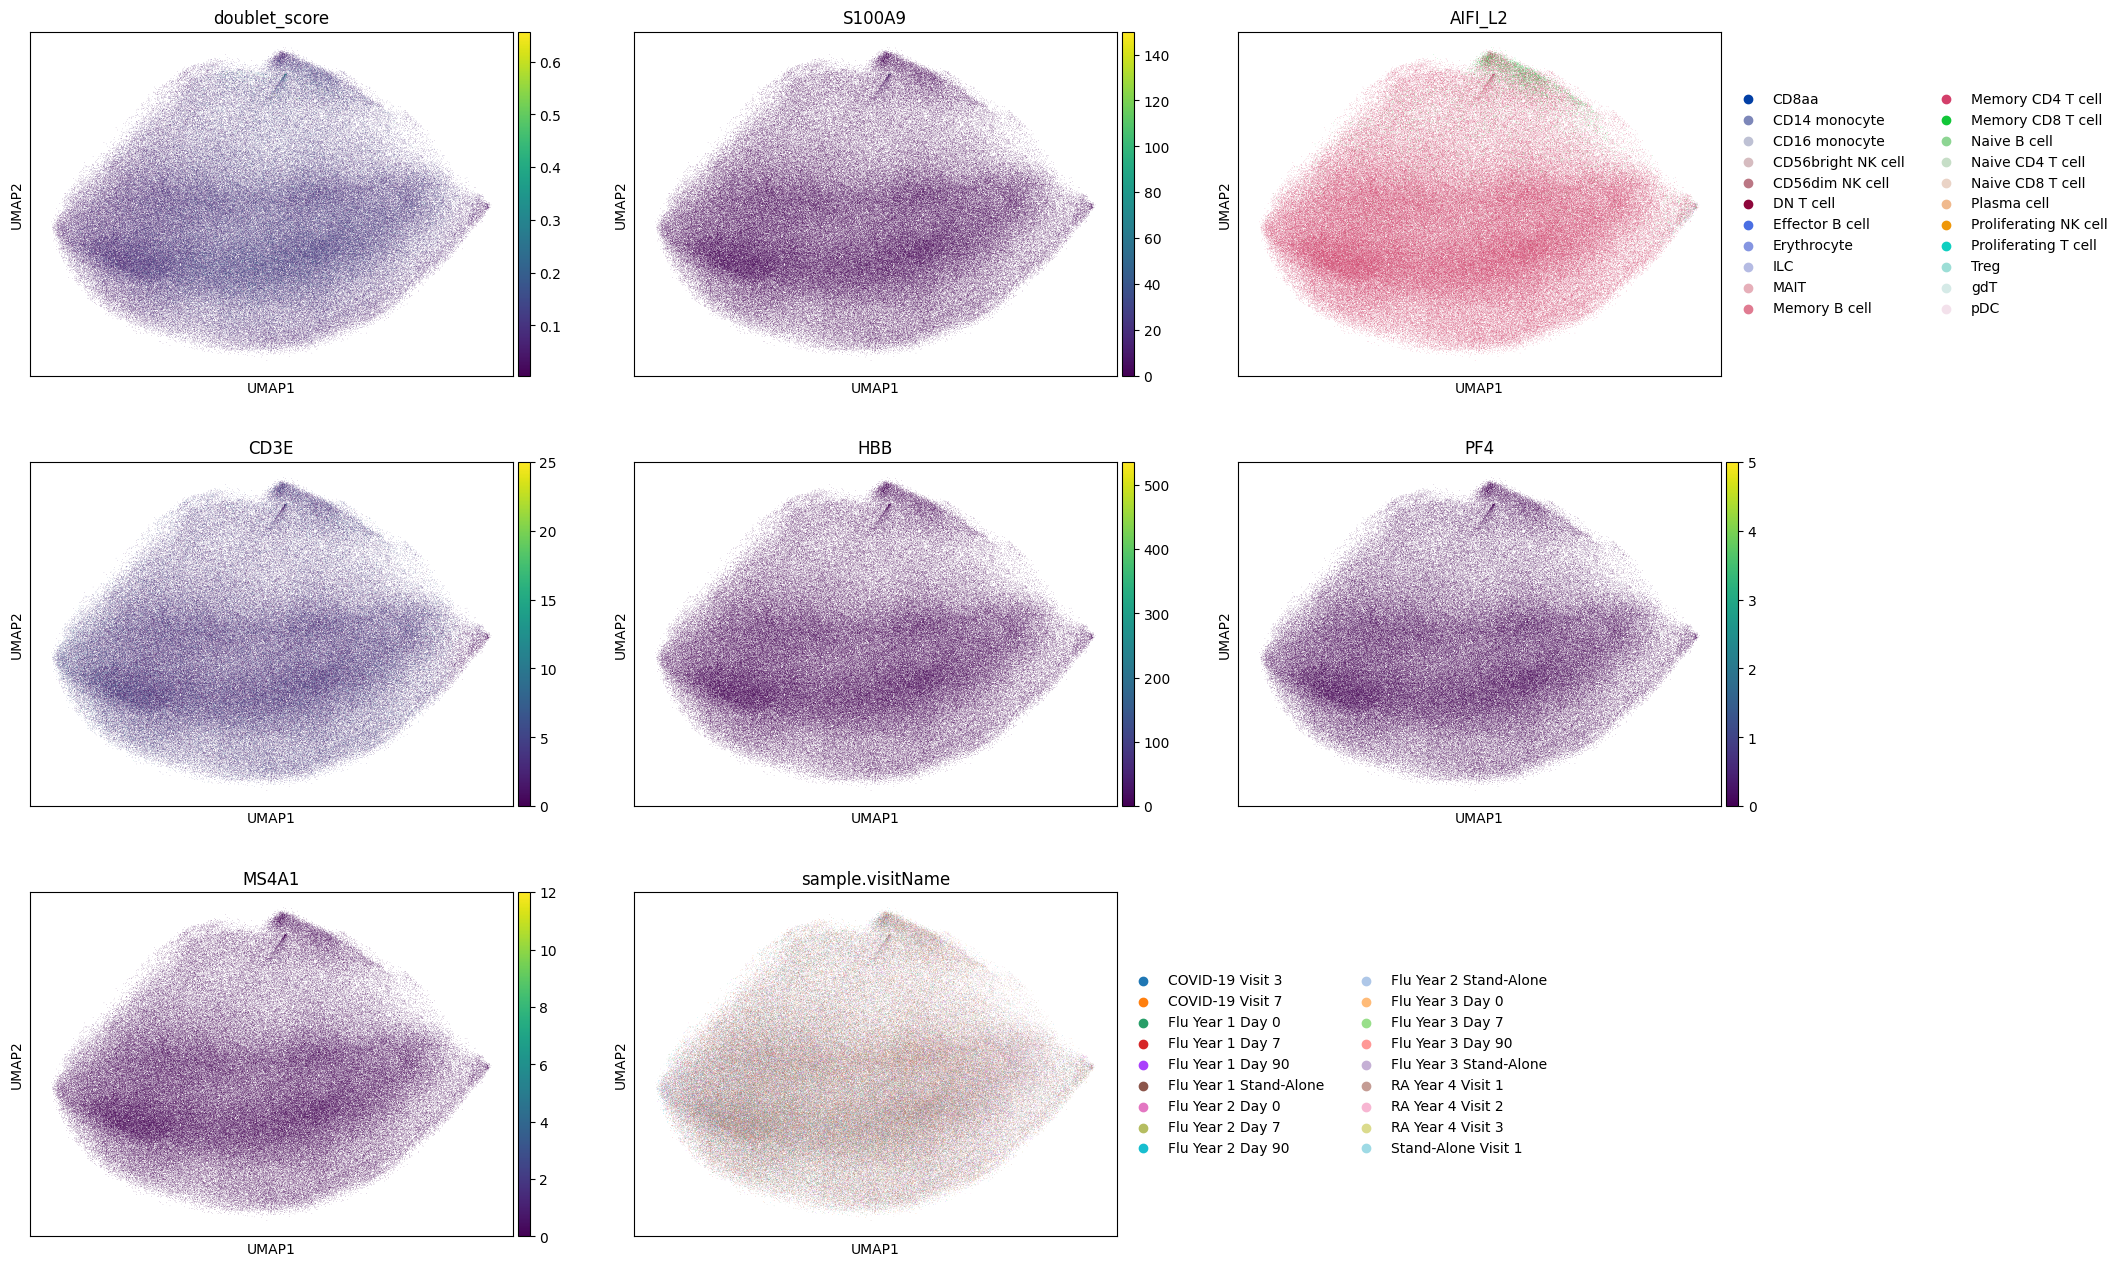

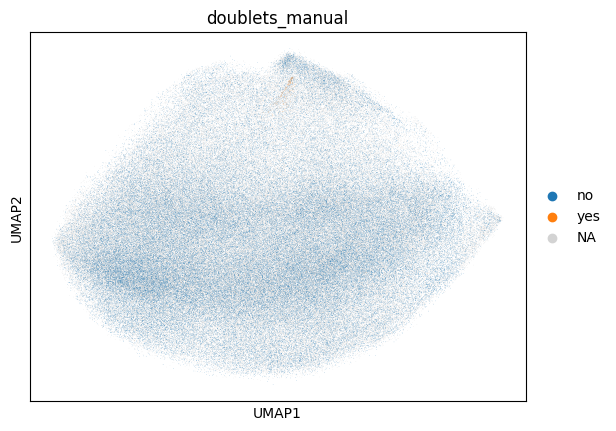

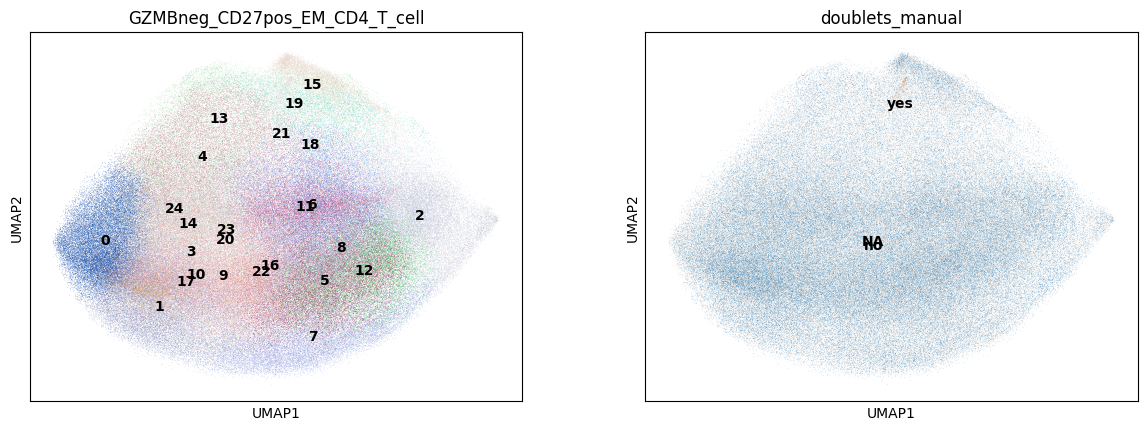

In [242]:
 p1 = sc.pl.umap(adata, 
               color=['doublet_score', 'S100A9','AIFI_L2' , 'CD3E',  
                      'HBB','PF4', 'MS4A1','sample.visitName'],
               ncols=3, 
              # save='_UMAP.png',
                    return_fig = True)

 p2 = sc.pl.umap(adata, 
           color=['doublets_manual'],
           ncols=3, 
           #save='_UMAP_leiden.png',
           #legend_loc='on data',
           return_fig = True,)

# Plot specifically for 'leiden' with legend on the data points
p3 = sc.pl.umap(adata, 
           color=['leiden_harmony_2', 'doublets_manual'],
           ncols=3, 
           #save='_UMAP_leiden.png',
           legend_loc='on data',return_fig = True,title = label)

umaps = (p3 + p2) / p1
umaps.show()

In [104]:
adata

AnnData object with n_obs × n_vars = 4270 × 33538
    obs: 'barcodes', 'batch_id', 'cell_name', 'cell_uuid', 'chip_id', 'hto_barcode', 'hto_category', 'n_genes', 'n_mito_umis', 'n_reads', 'n_umis', 'original_barcodes', 'pbmc_sample_id', 'pool_id', 'well_id', 'sample.sampleKitGuid', 'cohort.cohortGuid', 'subject.subjectGuid', 'subject.biologicalSex', 'subject.race', 'subject.ethnicity', 'subject.birthYear', 'sample.visitName', 'sample.drawDate', 'sample.diseaseStatesRecordedAtVisit', 'sample.daysSinceFirstVisit', 'file.id', 'subset_grp', 'predicted_doublet', 'doublet_score', 'AIFI_L1', 'AIFI_L1_score', 'AIFI_L2', 'AIFI_L2_score', 'AIFI_L3', 'AIFI_L3_score', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mito', 'log1p_total_counts_mito', 'pct_counts_mito', 'leiden_harmony_2', 'doublets_manual'
    uns: 'hvg', 'leid

In [125]:
df = sc.get.rank_genes_groups_df(adata, group=None)
df = df.groupby('group').head(20).reset_index(drop=True)
groups = df.groupby('group')
df

,group,names,scores,logfoldchanges,pvals,pvals_adj
0,0,MALAT1,20.612068,359.093262,9.905948e-70,3.322257e-65
1,0,RPL23,17.985369,12.386204,2.267433e-56,3.802259e-52
2,0,CCR7,17.441944,3.194196,3.723570e-53,3.131458e-49
3,0,RPL21,17.229986,24.431276,3.734818e-53,3.131458e-49
4,0,RPL9,16.391689,17.216669,3.853730e-49,2.584928e-45
...,...,...,...,...,...,...
375,18,LITAF,6.694835,2.579678,2.583074e-09,2.496575e-07
376,18,JAK1,6.694525,4.218787,2.601632e-09,2.507285e-07
377,18,PTPRC,6.653820,10.974524,3.114527e-09,2.917737e-07
378,18,UBB,6.632416,4.201779,3.388319e-09,3.165389e-07


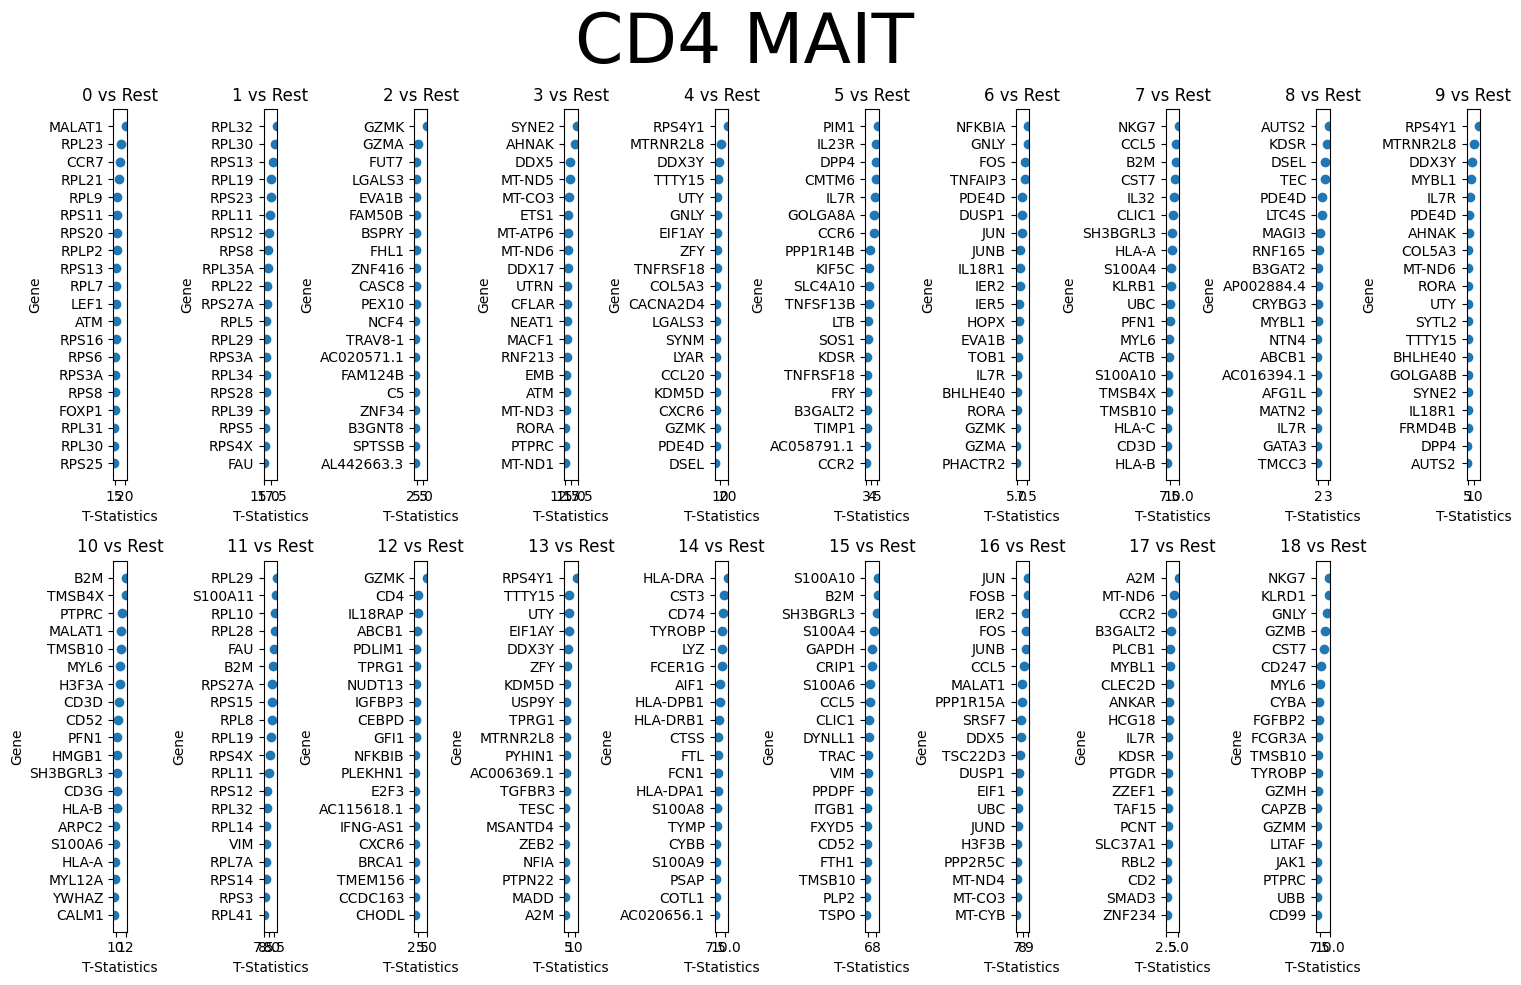

In [132]:
n_groups = len(groups)
n_cols = 10
n_rows = math.ceil(n_groups / n_cols)

fig, axs = plt.subplots(n_rows, n_cols, figsize=(15, n_rows * 5))
fig.suptitle(adata.obs['AIFI_L3'][0], fontsize=50)

if n_rows == 1:
    axs = axs.reshape(1, -1)

for ax in axs.flat:
    ax.set_visible(False)

for i, (name, group) in enumerate(groups):
    row, col = divmod(i, n_cols)
    ax = axs[row, col]
    ax.set_visible(True)
    ax.scatter(group['scores'], group['names'])
    ax.invert_yaxis()
    ax.set_title(str(name) + " vs Rest")
    ax.set_xlabel('T-Statistics')
    ax.set_ylabel('Gene')

plt.tight_layout()


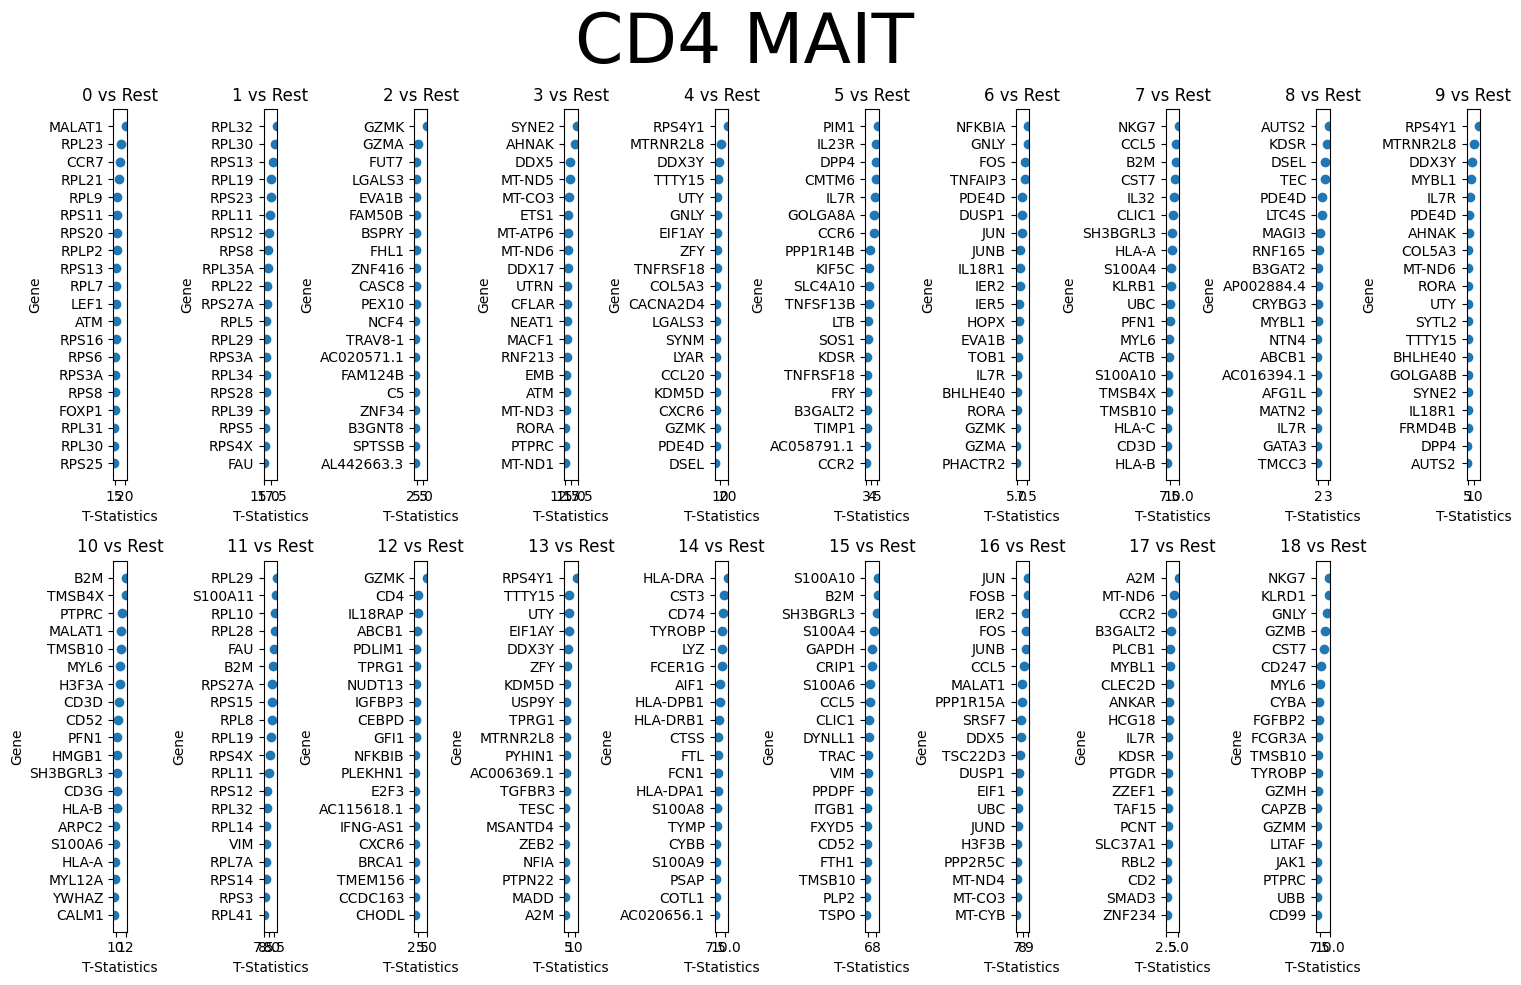

In [134]:
p = plot_rank_genes(adata=adata)